In [47]:
# load from dot env file
import os
from dotenv import load_dotenv
from neo4j import GraphDatabase
load_dotenv()

load_dotenv()
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
NEO4J_URI = os.getenv("NEO4J_URI")

In [48]:
def connect_to_neo4j():
    # Retrieve Neo4j connection details from environment variables
    uri = os.getenv("NEO4J_URI")
    username = os.getenv("NEO4J_USERNAME")
    password = os.getenv("NEO4J_PASSWORD")

    # Check if all required environment variables are set
    if not all([uri, username, password]):
        raise ValueError("Missing one or more required environment variables.")

    driver = GraphDatabase.driver(uri, auth=(username, password))
    try:
        driver.verify_connectivity()
        print(f"Connection successful! Connected to Neo4j at {uri}")
    except Exception as e:
        print(f"Failed to connect to Neo4j: {e}")
    
    return driver

In [49]:
# connect to Neo4j
driver = connect_to_neo4j()

Connection successful! Connected to Neo4j at neo4j+s://fef1ac8a.databases.neo4j.io


# Which environmental factors most strongly influence orgc and tceq?

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_environmental_data(driver, target='orgc'):
    query = f"""
    MATCH (o:Observation)-[:HAS_SOIL_PROPERTY]->(sp:SoilProperty)
    RETURN sp.{target} AS {target},
           sp.clay AS clay, sp.sand AS sand, sp.silt AS silt,
           sp.temperature AS temperature, sp.precipitation AS precipitation,
           sp.slope_mean AS slope
    ORDER BY sp.{target} DESC
    """
    with driver.session() as session:
        result = session.run(query)
        records = [r.data() for r in result]
    df = pd.DataFrame(records)
    
    # plot correlation heatmap
    corr = df.corr(numeric_only=True)

    # print the names of strongly correlated features
    # strong_corr = corr[target].abs().sort_values(ascending=False)
    # print(f"Strongly correlated features with {target}:")
    # for feature in strong_corr.index:
    #     if feature != target:
    #         print(f" - {feature}: {strong_corr[feature]}")

    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title(f'Correlation of Environmental Factors with {target}')
    plt.show()

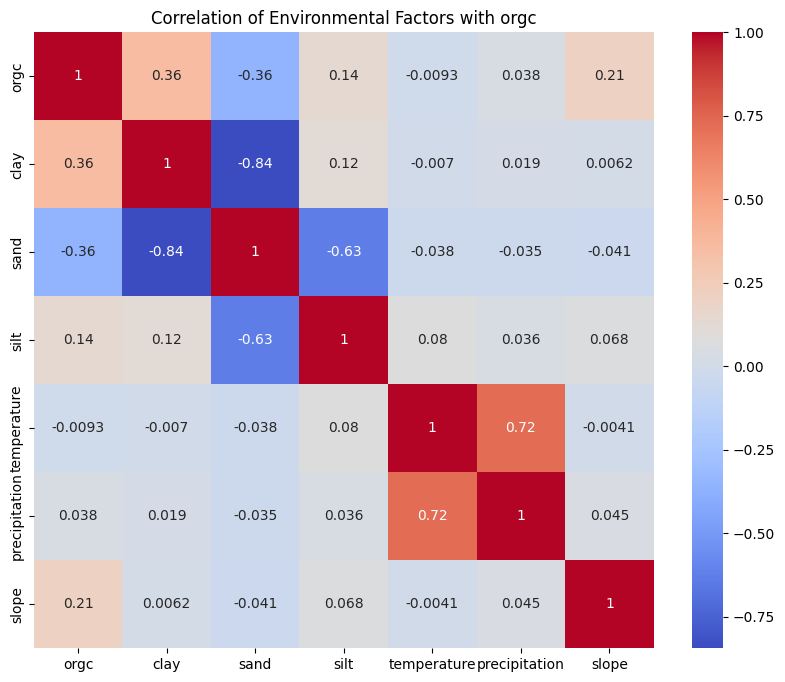

In [51]:
get_environmental_data(driver, target='orgc')

# What are the characteristics of locations with high orgc or high tceq?

In [52]:
def get_high_orgc_locations(driver, target='orgc', top_n=50):
    query = f"""
    MATCH (o:Observation)-[:HAS_SOIL_PROPERTY]->(s:SoilProperty)
    WITH avg(s.{target}) AS avg_orgc
    MATCH (o:Observation)-[:HAS_SOIL_PROPERTY]->(s:SoilProperty)
    WHERE s.{target} > avg_orgc
    RETURN s.clay as clay, s.sand as sand, s.silt as silt,
           s.temperature as temperature, s.precipitation as precipitation,
           s.landcover as landcover, s.orgc as orgc, s.slope_mean as slope_mean
    LIMIT {top_n}
    """
    
    with driver.session() as session:
        result = session.run(query)
        records = [r.data() for r in result]
    
    df = pd.DataFrame(records)
    
    # Create pairplot excluding landcover from numeric correlations
    numeric_cols = ['clay', 'sand', 'silt', 'temperature', 'precipitation', target, 'slope_mean']
    sns.pairplot(df[numeric_cols], diag_kind='kde')
    plt.suptitle(f'Characteristics of High {target} Locations', y=1.02)
    plt.show()
    
    return df

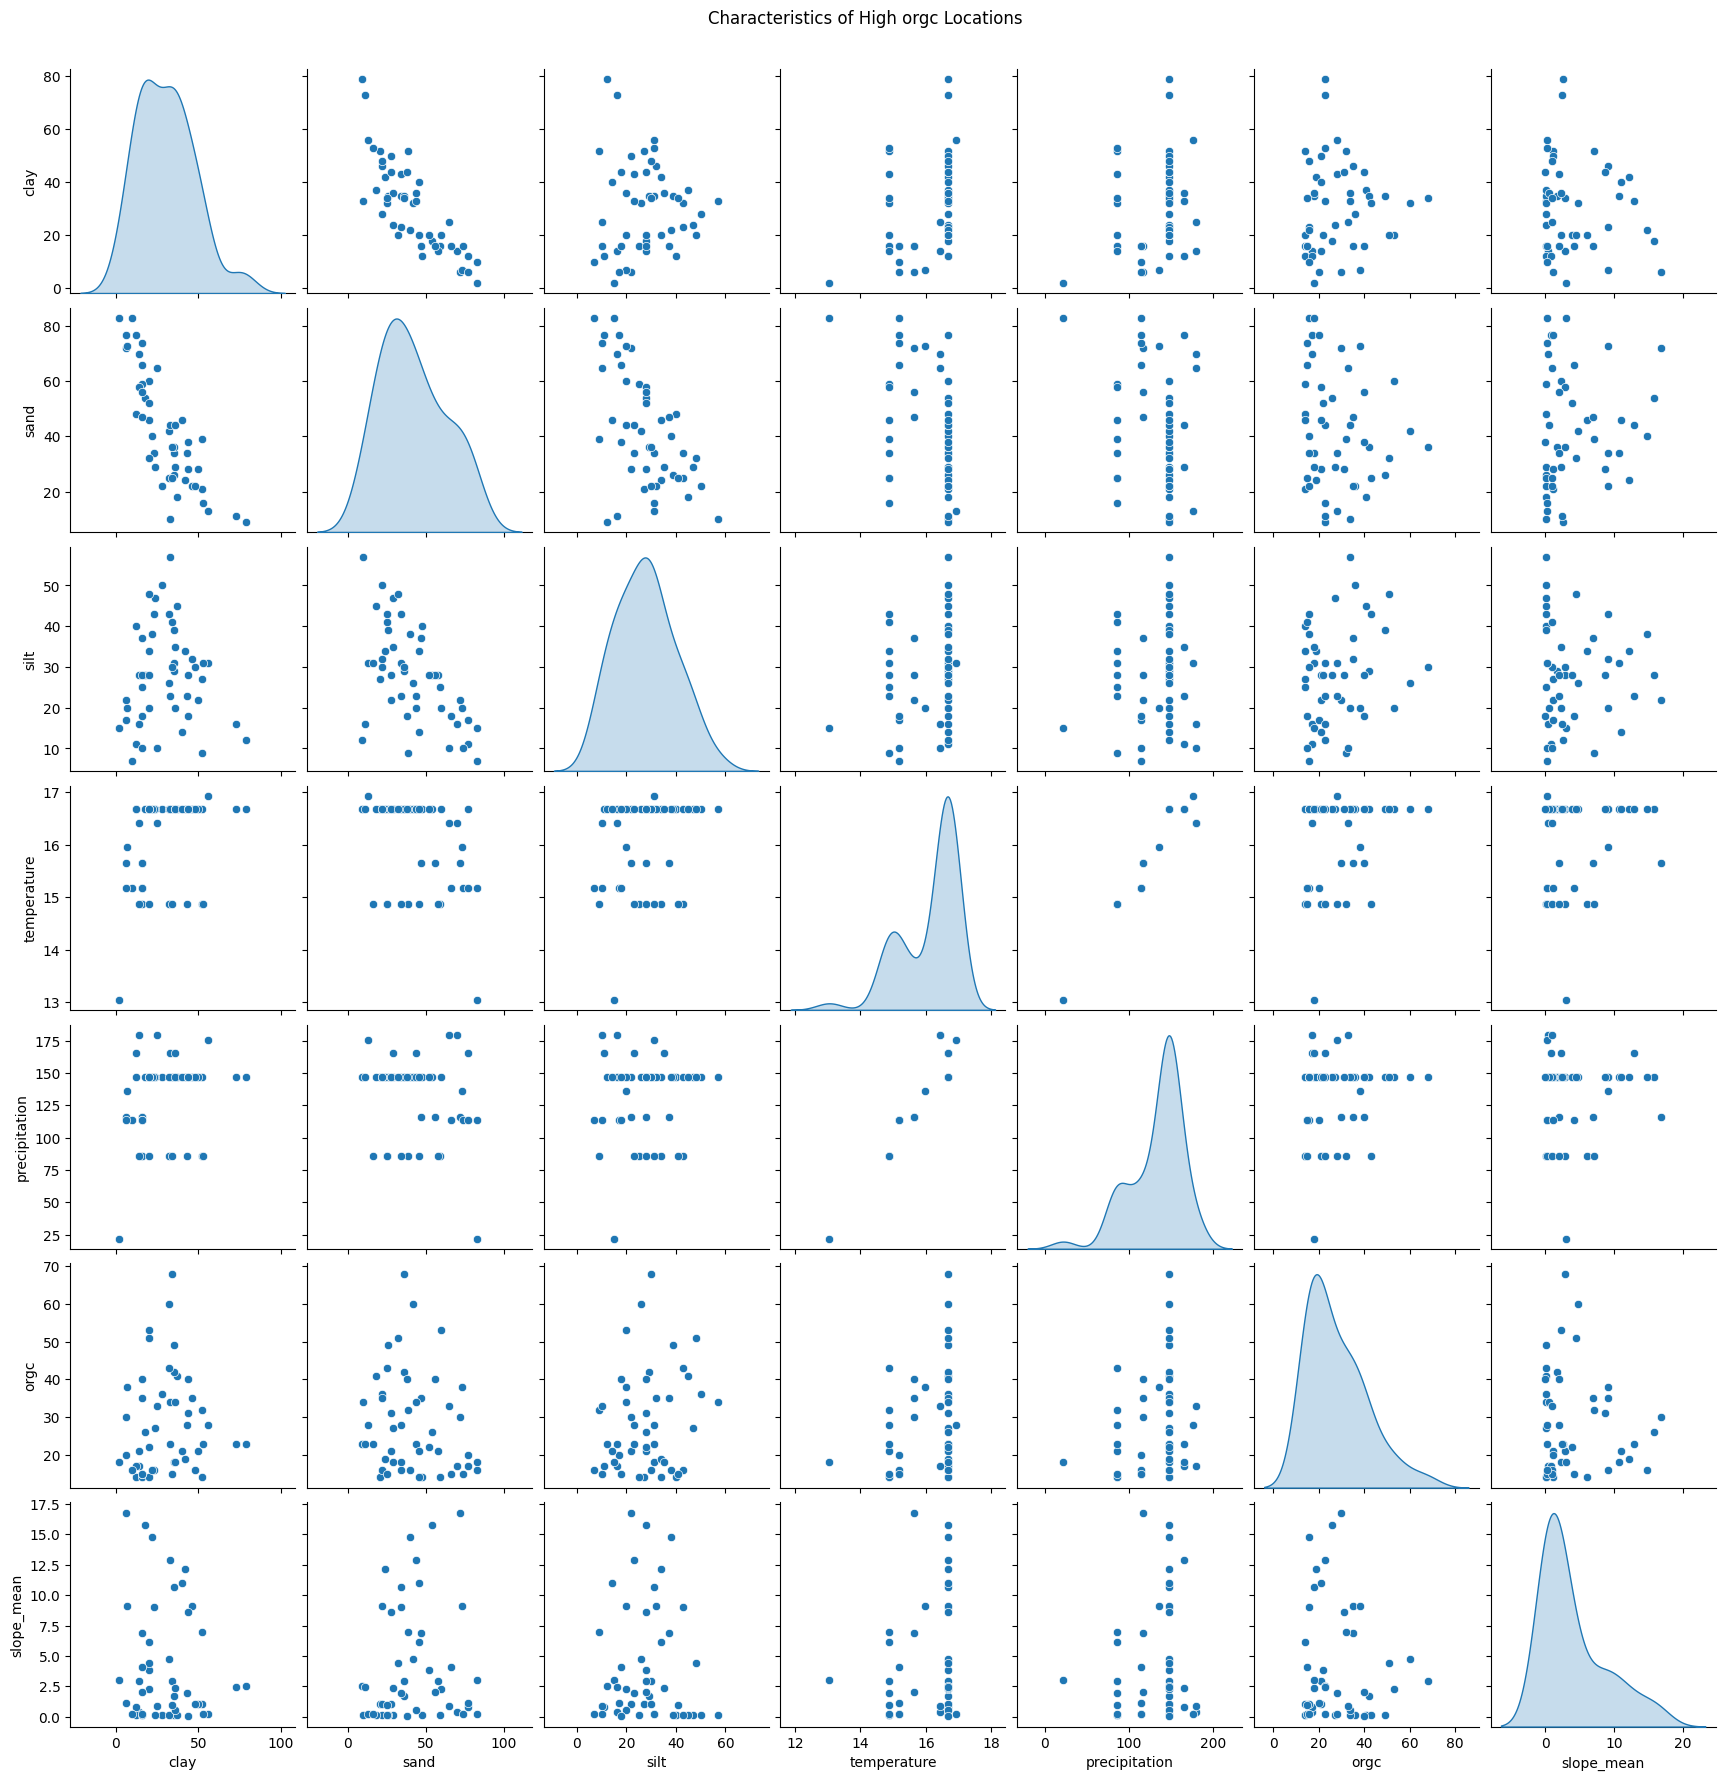

In [53]:
high_orgc_df = get_high_orgc_locations(driver, target='orgc', top_n=50)

# Do orgc stocks differ between managed and unmanaged land?

In [54]:
def compare_managed_unmanaged_land(driver):
    # Query to get orgc stats by land type
    query = """
    MATCH (o:Observation)-[:HAS_SOIL_PROPERTY]->(sp:SoilProperty)
    WHERE sp.orgc IS NOT NULL AND sp.landcover IS NOT NULL
    RETURN sp.landcover AS land_type,
           avg(sp.orgc) AS avg_orgc,
           stdev(sp.orgc) AS std_dev,
           count(*) AS n
    """
    
    # Execute query and create DataFrame
    with driver.session() as session:
        result = session.run(query)
        data = pd.DataFrame([r.data() for r in result])
    
    # Create bar plot with error bars
    plt.figure(figsize=(12, 6))
    
    # Plot bars
    bars = plt.bar(data['land_type'], data['avg_orgc'], 
                   yerr=data['std_dev'],
                   capsize=5,
                   alpha=0.7)
    
    # Customize plot
    plt.title('Average Organic Carbon Content by Land Type', fontsize=12)
    plt.xlabel('Land Type', fontsize=10)
    plt.ylabel('Average Organic Carbon Content (orgc)', fontsize=10)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom')
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')
    
    # Add grid for better readability
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    plt.show()

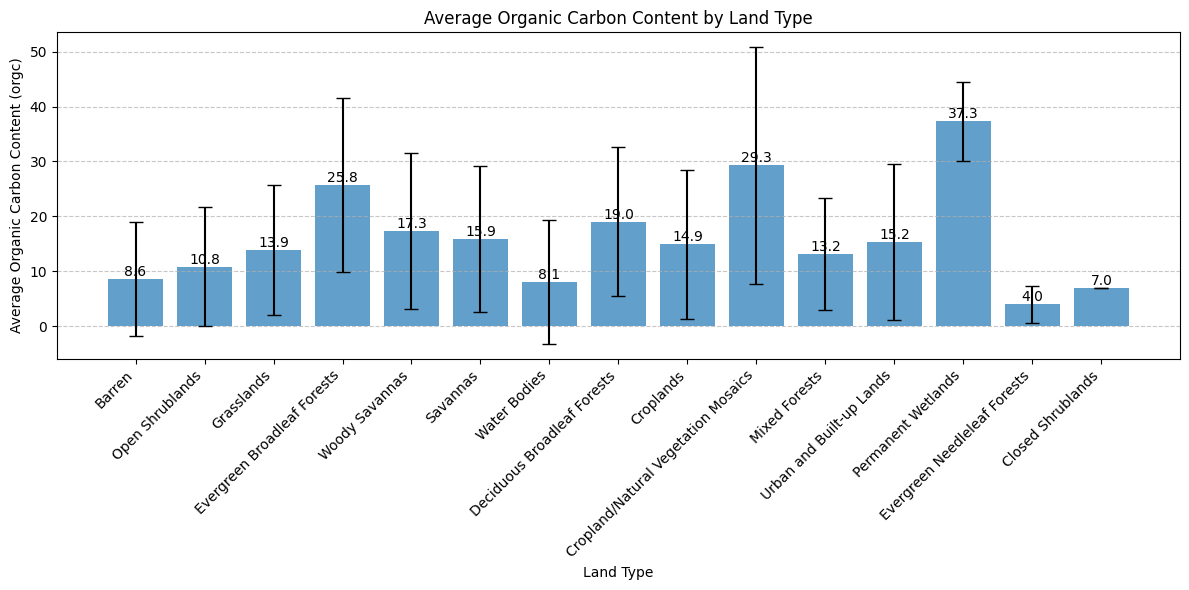

In [55]:
compare_managed_unmanaged_land(driver)

# Are orgc/tceq stocks consistently higher in arid vs humid regions?

In [56]:
def compare_climate_regions(driver):
    # Query to get orgc stats by climate type
    query = """
    MATCH (o:Observation)-[:HAS_SOIL_PROPERTY]->(sp:SoilProperty)
    WHERE sp.orgc IS NOT NULL AND sp.ecoregion IS NOT NULL
    RETURN sp.ecoregion AS climate_type,
        avg(sp.orgc) AS avg_orgc,
        stdev(sp.orgc) AS std_dev,
        count(*) AS n
    """
    
    # Execute query and create DataFrame
    with driver.session() as session:
        result = session.run(query)
        data = pd.DataFrame([r.data() for r in result])
    
    print(data.head())
    # Sort by average orgc for better visualization
    data = data.sort_values('avg_orgc', ascending=False)
    
    # Create figure with larger size
    plt.figure(figsize=(12, 6))
    
    # Create bar plot with error bars
    bars = plt.bar(data['climate_type'], data['avg_orgc'],
                   yerr=data['std_dev'],
                   capsize=5,
                   alpha=0.8,
                   color='skyblue',
                   ecolor='gray')
    
    # Customize plot
    plt.title('Average Organic Carbon Content by Climate Region', pad=20, fontsize=14)
    plt.xlabel('Climate Type', fontsize=12)
    plt.ylabel('Average Organic Carbon Content (orgc)', fontsize=12)
    
    # Add value labels on top of bars with sample size
    for bar in bars:
        height = bar.get_height()
        n = data.loc[data['avg_orgc'] == height, 'n'].iloc[0]
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'n={int(n)}\n{height:.1f}',
                ha='center', va='bottom')
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')
    
    # Add grid for better readability
    plt.grid(True, axis='y', linestyle='--', alpha=0.3)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()

    plt.show()
    
    # return data

                        climate_type   avg_orgc    std_dev     n
0                  Árida y semiárida   9.412111   9.148838  1701
1                 Templada subhúmeda  19.346535  15.508853   505
2  Inundable o Transición tierra-mar  13.482759  13.415398    29
3                    Tropical húmeda  23.660156  14.717394   256
4                 Tropical subhúmeda  17.194503  14.464898   473


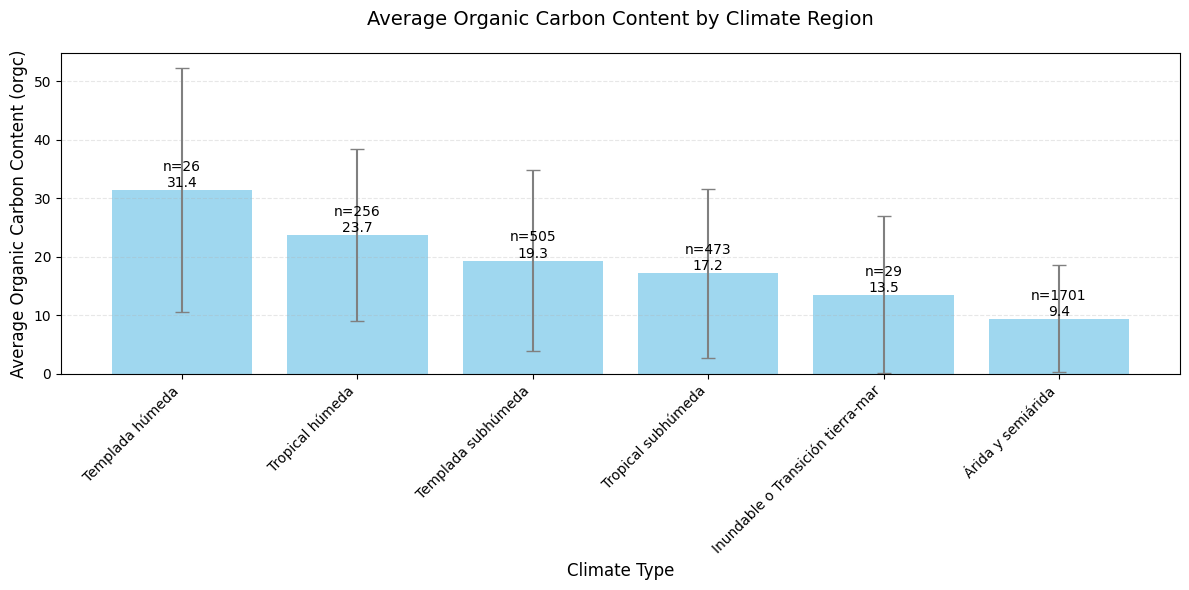

In [57]:
compare_climate_regions(driver)

# Which observations are inconsistent across similar locations?

# Which locations have anomalously low orgc given favorable conditions?

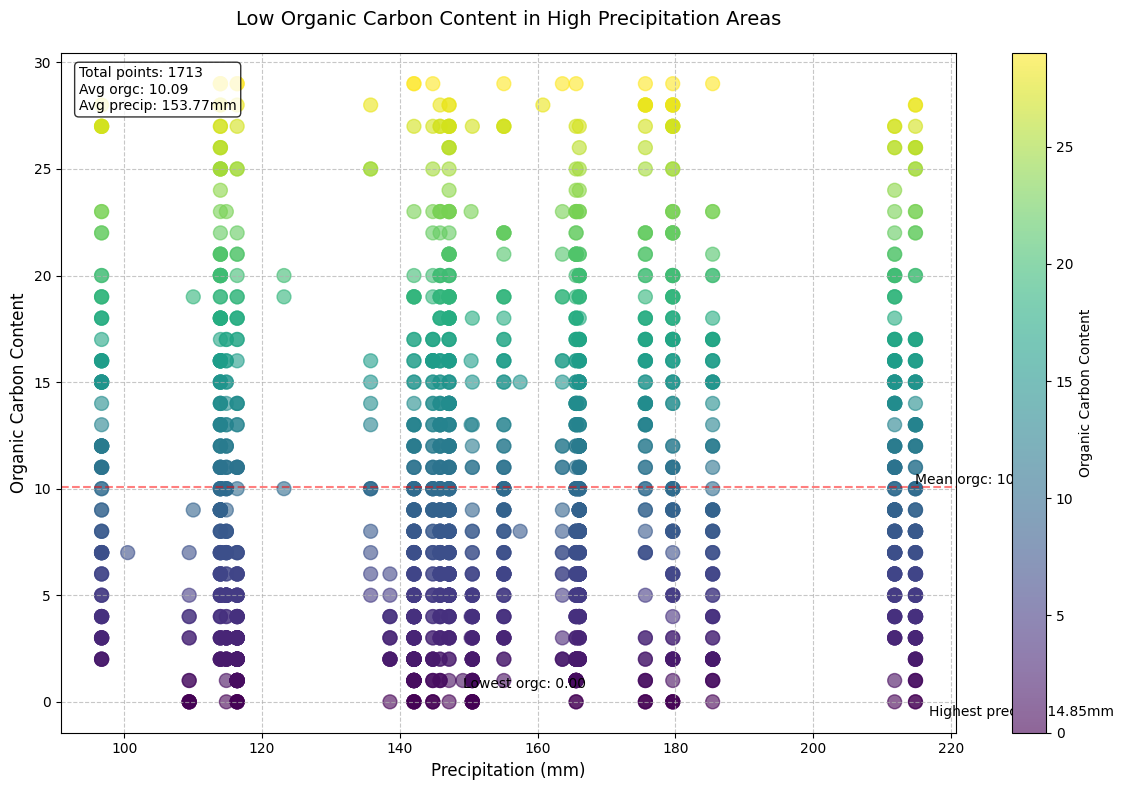

In [58]:
def plot_low_orgc_wet_areas(driver):
    # Query to get the data
    query = """
    MATCH (o:Observation)-[:HAS_SOIL_PROPERTY]->(sp:SoilProperty)
    WHERE sp.precipitation > 90 AND sp.orgc < 30
    MATCH (o)-[:HAS_LOCATION]->(l:Location)
    RETURN l.coordinates AS location, sp.orgc as orgc, sp.precipitation AS precipitation
    ORDER BY sp.orgc ASC
    """
    
    with driver.session() as session:
        result = session.run(query)
        data = pd.DataFrame([r.data() for r in result])
    
    # Create a larger figure
    plt.figure(figsize=(12, 8))
    
    # Create scatter plot
    scatter = plt.scatter(data['precipitation'], data['orgc'], 
                         alpha=0.6, 
                         c=data['orgc'],  # Color points by orgc value
                         cmap='viridis',
                         s=100)  # Increase point size
    
    # Add colorbar
    plt.colorbar(scatter, label='Organic Carbon Content')
    
    # Customize plot
    plt.title('Low Organic Carbon Content in High Precipitation Areas', 
              fontsize=14, pad=20)
    plt.xlabel('Precipitation (mm)', fontsize=12)
    plt.ylabel('Organic Carbon Content', fontsize=12)
    
    # Add grid
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Add mean line
    mean_orgc = data['orgc'].mean()
    plt.axhline(y=mean_orgc, color='r', linestyle='--', alpha=0.5)
    plt.text(data['precipitation'].max(), mean_orgc, 
            f'Mean orgc: {mean_orgc:.2f}', 
            verticalalignment='bottom')
    
    # Annotate some extreme points
    lowest_orgc = data.loc[data['orgc'].idxmin()]
    highest_precip = data.loc[data['precipitation'].idxmax()]
    
    plt.annotate(f'Lowest orgc: {lowest_orgc["orgc"]:.2f}',
                xy=(lowest_orgc['precipitation'], lowest_orgc['orgc']),
                xytext=(10, 10), textcoords='offset points')
    
    plt.annotate(f'Highest precip: {highest_precip["precipitation"]:.2f}mm',
                xy=(highest_precip['precipitation'], highest_precip['orgc']),
                xytext=(10, -10), textcoords='offset points')
    
    # Add text box with statistics
    stats_text = (f'Total points: {len(data)}\n'
                 f'Avg orgc: {data["orgc"].mean():.2f}\n'
                 f'Avg precip: {data["precipitation"].mean():.2f}mm')
    plt.text(0.02, 0.98, stats_text,
             transform=plt.gca().transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

plot_low_orgc_wet_areas(driver)

# Can orgc/tceq be inferred in data-sparse areas via interpolation?

# Can missing values in tceq stocks be predicted based on linked environmental factors?